# Artificial Neural Network from Scratch

In this notebook, I implemented a simple two-layer neural network and trained it on the MNIST digit recognizer dataset. It's meant to be an instructional example, through which you can understand the underlying math of neural networks better.

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
data = pd.read_csv('train.csv')

In [3]:
data

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
data.T

,0,1,2,3,4,5,6,7,8,9,...,41990,41991,41992,41993,41994,41995,41996,41997,41998,41999
label,1,0,1,4,0,0,7,3,5,3,...,3,1,9,6,4,0,1,7,6,9
pixel0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pixel1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pixel2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pixel3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pixel779,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pixel780,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pixel781,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pixel782,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data) # shuffle before splitting into dev and training sets

In [6]:
# into dev dataset for validation
data_dev = data[0:1000].T
data_dev

array([[4, 8, 9, ..., 2, 8, 2],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [7]:
data_dev.shape

(785, 1000)

In [8]:
Y_dev = data_dev[0]
Y_dev

array([4, 8, 9, 5, 0, 8, 6, 2, 2, 1, 0, 5, 3, 1, 0, 2, 2, 8, 9, 4, 5, 9,
       7, 1, 2, 0, 1, 0, 9, 4, 9, 1, 2, 4, 9, 0, 0, 1, 7, 7, 8, 8, 2, 4,
       6, 8, 8, 2, 2, 9, 6, 4, 7, 1, 0, 6, 2, 2, 3, 4, 4, 5, 7, 3, 3, 8,
       0, 6, 1, 5, 4, 4, 2, 9, 3, 6, 8, 8, 0, 7, 3, 0, 8, 6, 3, 7, 7, 4,
       3, 4, 5, 1, 1, 4, 3, 7, 3, 8, 7, 9, 7, 2, 7, 9, 4, 4, 8, 0, 9, 1,
       4, 4, 5, 0, 6, 4, 7, 1, 2, 0, 1, 3, 7, 6, 9, 2, 1, 1, 3, 5, 2, 3,
       7, 2, 1, 7, 3, 8, 9, 2, 3, 9, 2, 5, 8, 0, 2, 5, 7, 7, 7, 1, 9, 7,
       1, 8, 3, 3, 9, 9, 9, 0, 0, 6, 4, 3, 1, 2, 7, 9, 1, 1, 3, 8, 1, 1,
       7, 8, 1, 0, 4, 6, 2, 7, 0, 7, 7, 6, 6, 1, 4, 7, 7, 2, 9, 6, 8, 8,
       7, 8, 3, 8, 9, 8, 0, 0, 6, 8, 1, 6, 0, 6, 0, 8, 2, 0, 1, 3, 3, 8,
       2, 1, 0, 7, 9, 8, 9, 9, 7, 0, 3, 4, 0, 4, 4, 7, 4, 6, 3, 8, 6, 3,
       1, 1, 9, 3, 2, 4, 4, 5, 4, 2, 1, 9, 5, 0, 3, 3, 6, 5, 2, 9, 1, 3,
       1, 1, 8, 5, 4, 2, 4, 2, 3, 2, 0, 6, 8, 9, 3, 5, 7, 8, 3, 9, 5, 7,
       3, 0, 8, 2, 1, 9, 9, 1, 1, 0, 5, 6, 3, 9, 8,

In [9]:
X_dev = data_dev[1:n]
X_dev = X_dev / 255.
# traiing dataset
data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255.
_,m_train = X_train.shape

In [10]:
Y_train

array([7, 7, 2, ..., 0, 5, 0], dtype=int64)

Our NN will have a simple two-layer architecture. Input layer $a^{[0]}$ will have 784 units corresponding to the 784 pixels in each 28x28 input image. A hidden layer $a^{[1]}$ will have 10 units with ReLU activation, and finally our output layer $a^{[2]}$ will have 10 units corresponding to the ten digit classes with softmax activation.

**Forward propagation**

$$Z^{[1]} = W^{[1]} X + b^{[1]}$$
$$A^{[1]} = g_{\text{ReLU}}(Z^{[1]}))$$
$$Z^{[2]} = W^{[2]} A^{[1]} + b^{[2]}$$
$$A^{[2]} = g_{\text{softmax}}(Z^{[2]})$$

**Backward propagation**

$$dZ^{[2]} = A^{[2]} - Y$$
$$dW^{[2]} = \frac{1}{m} dZ^{[2]} A^{[1]T}$$
$$dB^{[2]} = \frac{1}{m} \Sigma {dZ^{[2]}}$$
$$dZ^{[1]} = W^{[2]T} dZ^{[2]} .* g^{[1]\prime} (z^{[1]})$$
$$dW^{[1]} = \frac{1}{m} dZ^{[1]} A^{[0]T}$$
$$dB^{[1]} = \frac{1}{m} \Sigma {dZ^{[1]}}$$

**Parameter updates**

$$W^{[2]} := W^{[2]} - \alpha dW^{[2]}$$
$$b^{[2]} := b^{[2]} - \alpha db^{[2]}$$
$$W^{[1]} := W^{[1]} - \alpha dW^{[1]}$$
$$b^{[1]} := b^{[1]} - \alpha db^{[1]}$$

**Vars and shapes**

Forward prop

- $A^{[0]} = X$: 784 x m
- $Z^{[1]} \sim A^{[1]}$: 10 x m
- $W^{[1]}$: 10 x 784 (as $W^{[1]} A^{[0]} \sim Z^{[1]}$)
- $B^{[1]}$: 10 x 1
- $Z^{[2]} \sim A^{[2]}$: 10 x m
- $W^{[1]}$: 10 x 10 (as $W^{[2]} A^{[1]} \sim Z^{[2]}$)
- $B^{[2]}$: 10 x 1

Backprop

- $dZ^{[2]}$: 10 x m ($~A^{[2]}$)
- $dW^{[2]}$: 10 x 10
- $dB^{[2]}$: 10 x 1
- $dZ^{[1]}$: 10 x m ($~A^{[1]}$)
- $dW^{[1]}$: 10 x 10
- $dB^{[1]}$: 10 x 1

In [11]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A
    
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def ReLU_deriv(Z):
    return Z > 0

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1    
    W2 = W2 - alpha * dW2  
    b2 = b2 - alpha * db2    
    return W1, b1, W2, b2

In [12]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [13]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 500)

Iteration:  0
[0 0 0 ... 0 7 0] [7 7 2 ... 0 5 0]
0.0986829268292683
Iteration:  10
[8 2 2 ... 2 7 0] [7 7 2 ... 0 5 0]
0.185
Iteration:  20
[8 2 2 ... 2 7 0] [7 7 2 ... 0 5 0]
0.22875609756097562
Iteration:  30
[8 2 2 ... 2 7 0] [7 7 2 ... 0 5 0]
0.2747317073170732
Iteration:  40
[8 2 2 ... 2 7 0] [7 7 2 ... 0 5 0]
0.33314634146341465
Iteration:  50
[8 2 2 ... 0 7 0] [7 7 2 ... 0 5 0]
0.40363414634146344
Iteration:  60
[8 2 2 ... 0 7 0] [7 7 2 ... 0 5 0]
0.45795121951219514
Iteration:  70
[8 2 2 ... 0 7 0] [7 7 2 ... 0 5 0]
0.5008536585365854
Iteration:  80
[8 4 2 ... 0 7 0] [7 7 2 ... 0 5 0]
0.5387560975609756
Iteration:  90
[5 4 2 ... 0 7 0] [7 7 2 ... 0 5 0]
0.573560975609756
Iteration:  100
[5 4 2 ... 0 7 0] [7 7 2 ... 0 5 0]
0.600170731707317
Iteration:  110
[5 4 2 ... 0 7 0] [7 7 2 ... 0 5 0]
0.6230243902439024
Iteration:  120
[5 4 2 ... 0 7 0] [7 7 2 ... 0 5 0]
0.6400975609756098
Iteration:  130
[5 4 2 ... 0 7 0] [7 7 2 ... 0 5 0]
0.6562439024390244
Iteration:  140
[5 4 2 ... 0

~85% accuracy on training set.

In [14]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Let's look at a couple of examples:

Prediction:  [7]
Label:  7


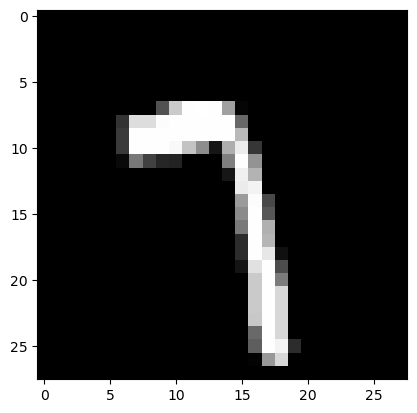

Prediction:  [7]
Label:  7


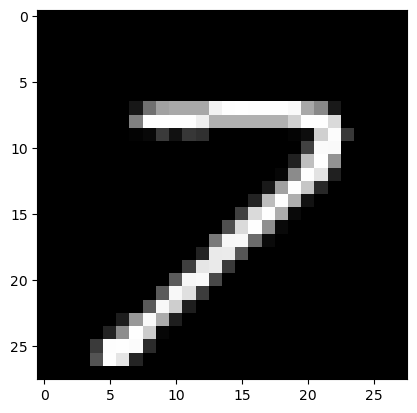

Prediction:  [2]
Label:  2


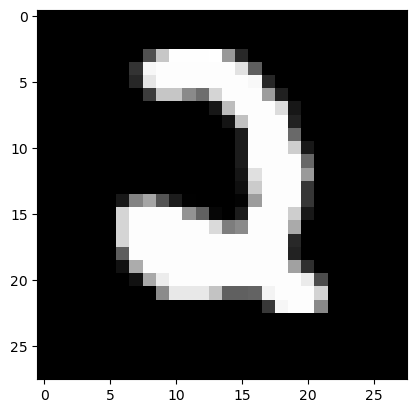

Prediction:  [5]
Label:  5


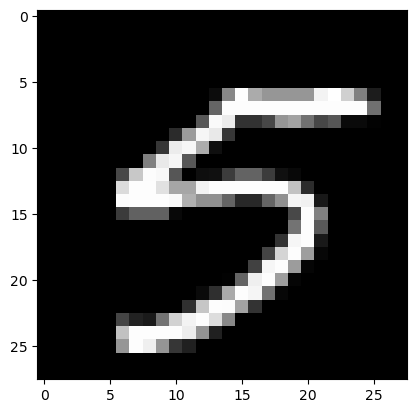

In [15]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)

Finally, let's find the accuracy on the dev set:

In [16]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_dev)

[4 8 9 5 0 3 6 2 2 1 0 5 3 1 0 2 2 8 9 4 5 9 7 1 2 0 1 0 7 4 9 1 2 4 7 0 0
 1 7 9 5 8 2 4 6 8 0 2 2 4 6 9 7 1 0 6 2 2 3 4 4 5 7 8 3 5 0 6 1 9 0 9 2 9
 3 2 8 5 3 7 3 0 0 6 6 7 7 4 3 4 5 1 1 4 3 7 3 8 9 2 7 7 7 9 4 4 8 0 9 1 4
 4 8 0 6 4 7 1 4 0 1 3 7 6 9 2 1 1 3 5 2 3 7 2 1 7 3 8 9 2 3 9 9 8 8 0 2 5
 7 7 7 1 9 7 1 4 3 3 5 9 9 0 0 6 4 8 1 2 7 9 1 1 3 8 1 8 7 8 1 0 4 6 2 7 0
 2 7 6 6 1 9 7 7 2 9 6 3 8 7 8 8 8 9 8 0 0 6 5 1 6 0 6 0 8 2 0 1 3 3 8 2 1
 0 7 3 9 9 9 9 0 3 4 0 0 4 7 4 6 3 0 6 1 1 3 9 3 2 4 4 5 4 8 1 9 5 0 3 3 6
 5 2 9 1 3 1 1 8 5 4 2 9 2 3 8 0 6 8 9 3 5 7 5 3 9 5 7 3 0 3 2 1 9 9 1 1 0
 5 6 1 9 8 5 1 9 7 8 5 2 0 5 6 1 0 1 0 3 5 6 3 0 0 4 3 2 2 9 0 8 7 5 7 4 6
 7 3 8 4 5 1 7 1 8 1 7 2 2 9 0 1 4 8 3 2 5 7 9 3 6 1 7 2 5 3 4 3 4 9 3 6 8
 8 2 4 6 0 0 7 3 0 7 7 3 6 3 8 6 8 3 3 2 1 3 7 2 8 0 9 7 5 7 6 3 7 9 8 1 3
 2 4 3 8 1 6 2 7 9 7 4 0 2 4 5 0 7 6 4 6 5 4 5 2 2 2 0 0 3 4 3 0 0 1 0 3 0
 9 1 6 3 9 4 5 8 7 9 9 4 7 3 7 8 8 6 4 5 8 1 5 0 2 8 7 8 5 4 3 5 3 5 6 6 0
 8 8 6 5 2 2 4 4 9 5 9 6 

0.843

Still 84% accuracy, so our model generalized from the training data pretty well.

# ANN with Tensoorflow

In [ ]:
#important libraries
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [ ]:
(X_train,y_train),(X_test,y_test)=keras.datasets.mnist.load_data()

In [ ]:
len(X_train)

In [ ]:
len(X_test)

In [ ]:
#shape of images
X_train[0].shape #28*28 pixels

In [ ]:
X_train[0]

In [ ]:
#plot taining images
plt.matshow(X_train[0])

In [ ]:
y_train[0]

In [ ]:
y_train[0:10]

In [ ]:
#flatten train and test data from 2d to 1d
X_train.shape

In [ ]:
#Scalling value to between 0 and 1 so it will be easy for training on small merge area
X_train=X_train/255
X_test=X_test/255

In [ ]:
X_train[0]

In [ ]:
X_train_flattend=X_train.reshape(len(X_train),28*28)
X_test_flattend=X_test.reshape(len(X_test),28*28)
X_train_flattend
X_test_flattend

In [ ]:
X_train_flattend.shape
X_test_flattend.shape
#get 784 element 1d

In [ ]:
X_train_flattend[0]

In [ ]:
#Define simple neural network consist of 1one input layer(784neuron) and one output layer(10 neurons)
model=keras.Sequential([
                  keras.layers.Dense(10,input_shape=(784,),activation="softmax")#input and output layer
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(X_train_flattend,y_train,epochs=5)

In [ ]:
model.evaluate(X_test_flattend,y_test)

In [ ]:
plt.matshow(X_test[1])

In [ ]:
y_predict=model.predict(X_test_flattend)
y_predict[1]

In [ ]:
np.argmax(y_predict[1])

In [ ]:
y_predict_labels=[np.argmax(i) for i in y_predict]
y_predict_labels[:6]

In [ ]:
#Confusion Matrix
cm=tf.math.confusion_matrix(labels=y_test,predictions=y_predict_labels)
cm

In [ ]:
#Confusion Matrix Ploting
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [ ]:
#Define simple neural network consist of 1one input layer(784neuron) and one output layer(10 neurons)
model=keras.Sequential([
                  keras.layers.Dense(100,input_shape=(784,),activation="relu"),# hidden layer
                  keras.layers.Dense(80,activation="relu"),# hidden layer
                   keras.layers.Dense(50,activation="relu"),# hidden layer
                  keras.layers.Dense(10,activation="sigmoid")#output layer
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(X_train_flattend,y_train,epochs=15)

In [ ]:
model.summary()

In [ ]:
model.evaluate(X_test_flattend,y_test)

In [ ]:
#Confusion Matrix Ploting,See the difference
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [ ]:
model.save("digit_classifier.h5")

In [ ]:
# load model 
loaded_model = tf.keras.models.load_model('digit_classifier.h5')


In [ ]:
loaded_model

In [ ]:
# Check the model summary
loaded_model.summary()